### 5G 用户判断：LGB+神经网络加权融合 AUC93.12%

In [26]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  

### 1. 数据加载与特征工程

- **缺失值处理**：连续特征使用中位数填充，类别特征使用 -1 填充。
- **极值平滑 (双重对数平滑)**：对所有的数值型特征应用 `log1p(log1p(x))`，将长尾分布和异常极值正态化。提升模型稳定性
- **cat_12浮点值**:cat_12存在大量（接近13%）浮点型数据，将此类异常标记为-1以适配离散数据。

Loading dataset...


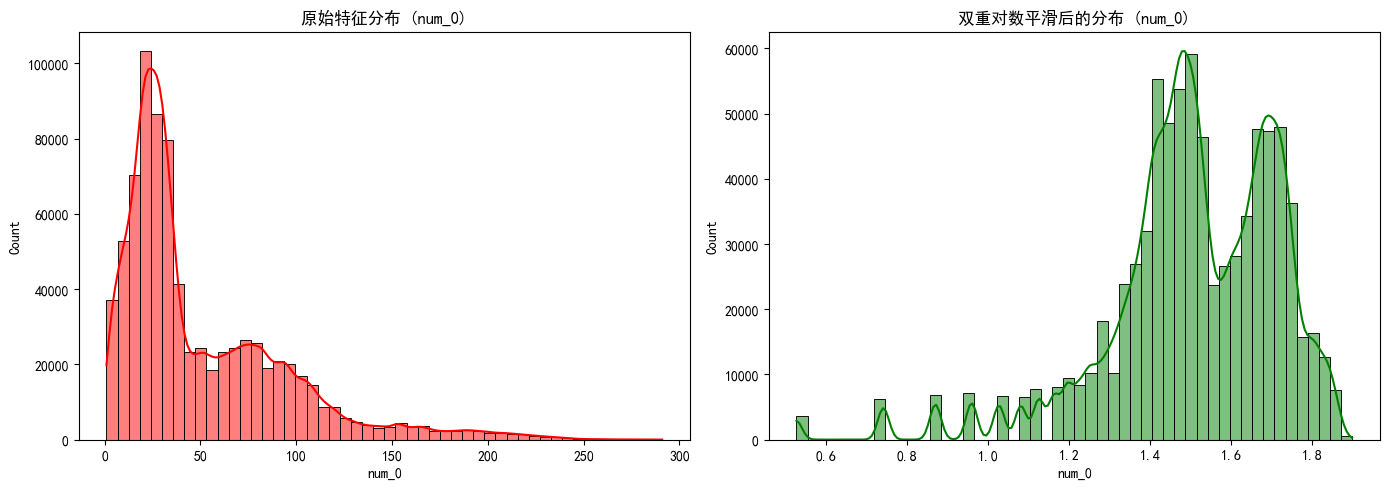

特征工程进行中...
特征矩阵形状: (800000, 58)


In [27]:
print("Loading dataset...")
df = pd.read_csv('train.csv')

cat_cols = [f'cat_{i}' for i in range(20)]
num_cols = [f'num_{i}' for i in range(38)]

# 双重对数平滑效果
sample_feature = 'num_0'

plt.figure(figsize=(14, 5))

# 原始分布
plt.subplot(1, 2, 1)
sns.histplot(df[sample_feature], bins=50, kde=True, color='red')
plt.title(f"原始特征分布 ({sample_feature})")

# 平滑后分布
transformed_feature = np.log1p(np.log1p(np.clip(df[sample_feature], a_min=0, a_max=None)))
plt.subplot(1, 2, 2)
sns.histplot(transformed_feature, bins=50, kde=True, color='green')
plt.title(f"双重对数平滑后的分布 ({sample_feature})")

plt.tight_layout()
plt.show()

X = df.drop(columns=['id', 'target'])
y = df['target'].values

print("特征工程进行中...")
# # 连续特征缺失值填充
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

X["cat_12"] = X["cat_12"].fillna(-1)
X.loc[X["cat_12"] != X["cat_12"].astype(int), "cat_12"] = -1

# 类别特征缺失值填充与类型转换 (截断 cat_12 的小数部分)
X[cat_cols] = X[cat_cols].fillna(-1).astype(int)

# 连续特征长尾分布抑制 (双重对数平滑)
X[num_cols] = np.log1p(np.log1p(np.clip(X[num_cols], a_min=0, a_max=None)))

print(f"特征矩阵形状: {X.shape}")

### 2. 数据切分

使用固定的随机种子（可复现），以 8:2 的比例切分训练集与验证集。

In [28]:
RANDOM_SEED = 999
print(f"随机种子={RANDOM_SEED}...")
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
print(f"训练集: {X_train.shape}, 测试集: {X_valid.shape}")

随机种子=999...
训练集: (640000, 58), 测试集: (160000, 58)


### 3. 模型训练：LightGBM

**参数设置说明：**
- `learning_rate=0.05`：适中的学习率，配合 1000 棵树进行平缓、深度的特征交互。
- `num_leaves=64`：树的复杂度设定较高。由于我们的训练集高达 64 万条数据，较大的叶子数能充分挖掘交叉特征而不至于轻易过拟合。
- `reg_lambda=10`：为了平衡高 `num_leaves` 带来的过拟合风险，施加了较强的 L2 正则化约束模型发散。
- `class_weight='balanced'`：针对目标变量（5G 用户）的正负样本不平衡问题进行自动权重补偿。

In [29]:
print(f"\n[1/2] 训练 LightGBM 模型...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    reg_lambda=10,
    min_child_weight=6,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=4,
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

lgb_valid_preds = lgb_model.predict_proba(X_valid)[:, 1]
lgb_auc = roc_auc_score(y_valid, lgb_valid_preds)
print(f"LightGBM AUC: {lgb_auc:.5f}")


[1/2] 训练 LightGBM 模型...
[LightGBM] [Info] Number of positive: 8480, number of negative: 631520
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.090560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9201
[LightGBM] [Info] Number of data points in the train set: 640000, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LightGBM AUC: 0.93036


### 4. 模型训练：Tabular Neural Network

基于 Entity Embedding 构建的适用于表格数据的深度学习模型。

In [30]:
print("\n[2/2] 训练神经网络...")

# 连续特征标准化
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_train[num_cols])
X_valid_num_scaled = scaler.transform(X_valid[num_cols])

# 类别特征编码映射
X_cat_encoded = X[cat_cols].copy()
cat_dims = []
for col in cat_cols:
    unique_cats = X[col].unique()
    mapping = {val: i for i, val in enumerate(unique_cats)}
    X_cat_encoded[col] = X[col].map(mapping).astype(int)
    cat_dims.append(len(unique_cats))

emb_dims = [(dim, min(50, (dim + 1) // 2)) for dim in cat_dims]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class TabularDataset(Dataset):
    def __init__(self, cat_data, num_data, labels):
        self.cat_data = torch.tensor(cat_data.values, dtype=torch.long)
        self.num_data = torch.tensor(num_data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.cat_data)
    def __getitem__(self, idx): 
        return self.cat_data[idx], self.num_data[idx], self.labels[idx]

class TabularNN(nn.Module):
    def __init__(self, emb_dims, num_continuous):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(classes, emb_dim) for classes, emb_dim in emb_dims])
        total_emb_dim = sum(e[1] for e in emb_dims)
        self.mlp = nn.Sequential(
            nn.Linear(total_emb_dim + num_continuous, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, x_cat, x_num):
        x_emb = torch.cat([emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.embeddings)], 1)
        return self.mlp(torch.cat([x_emb, x_num], 1)).squeeze()

train_idx = X_train.index
valid_idx = X_valid.index

train_loader = DataLoader(TabularDataset(X_cat_encoded.loc[train_idx], X_num_scaled, y_train), batch_size=1024, shuffle=True)
valid_loader = DataLoader(TabularDataset(X_cat_encoded.loc[valid_idx], X_valid_num_scaled, y_valid), batch_size=2048, shuffle=False)

nn_model = TabularNN(emb_dims, len(num_cols)).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

best_nn_auc = 0
nn_valid_preds = None
epochs = 10  # 10 轮

for epoch in range(epochs):
    nn_model.train()
    for x_c, x_n, labels in train_loader:
        x_c, x_n, labels = x_c.to(device), x_n.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(nn_model(x_c, x_n), labels)
        loss.backward()
        optimizer.step()
        
    nn_model.eval()
    all_preds = []
    with torch.no_grad():
        for x_c, x_n, _ in valid_loader:
            all_preds.extend(nn_model(x_c.to(device), x_n.to(device)).cpu().numpy())
    val_auc = roc_auc_score(y_valid, all_preds)
    print(f"Epoch {epoch+1}/{epochs} - Valid AUC: {val_auc:.5f}")
    if val_auc > best_nn_auc:
        best_nn_auc = val_auc
        nn_valid_preds = np.array(all_preds)

print(f"神经网络 AUC: {best_nn_auc:.5f}")


[2/2] 训练神经网络...
Epoch 1/10 - Valid AUC: 0.89782
Epoch 2/10 - Valid AUC: 0.90489
Epoch 3/10 - Valid AUC: 0.91151
Epoch 4/10 - Valid AUC: 0.91170
Epoch 5/10 - Valid AUC: 0.91118
Epoch 6/10 - Valid AUC: 0.91425
Epoch 7/10 - Valid AUC: 0.91262
Epoch 8/10 - Valid AUC: 0.91394
Epoch 9/10 - Valid AUC: 0.91370
Epoch 10/10 - Valid AUC: 0.91350
神经网络 AUC: 0.91425


### 5. 模型融合 (Ensemble) 与可视化

采用加权平均 (Weighted Average) 的方式进行模型结果融合，并绘制预测概率分布图，以直观观察模型区分能力与多模型差异。


--- 融合模型 ---
权重 -> LightGBM: 0.6, Neural Network: 0.4

融合模型 AUC: 0.931435


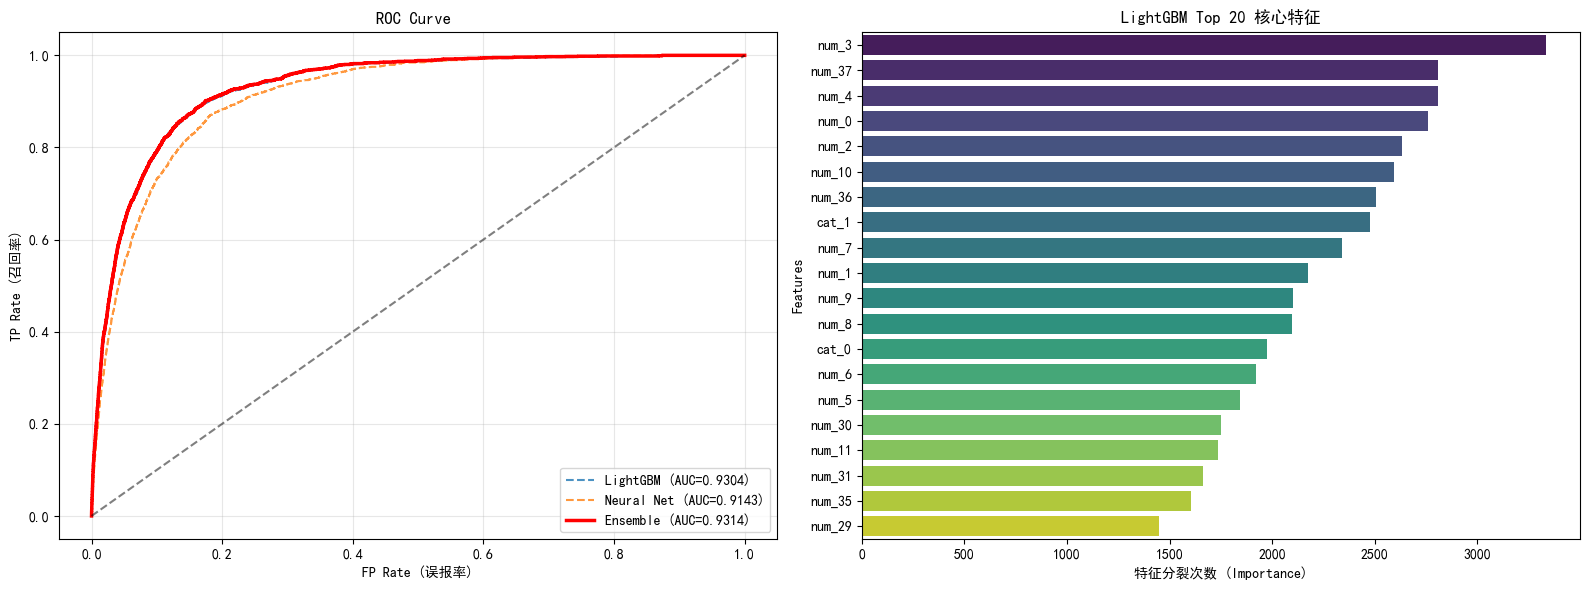

In [ ]:
W_LGB = 0.4
W_NN  = 0.6

print("\n--- 融合模型 ---")
print(f"权重 -> LightGBM: {W_LGB}, Neural Network: {W_NN}")

ensemble_valid_preds = W_LGB * lgb_valid_preds + W_NN * nn_valid_preds
final_valid_auc = roc_auc_score(y_valid, ensemble_valid_preds)
print(f"\n融合模型 AUC: {final_valid_auc:.6f}")

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 绘制 ROC 曲线
fpr_lgb, tpr_lgb, _ = roc_curve(y_valid, lgb_valid_preds)
fpr_nn, tpr_nn, _ = roc_curve(y_valid, nn_valid_preds)
fpr_ens, tpr_ens, _ = roc_curve(y_valid, ensemble_valid_preds)

axes[0].plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC={lgb_auc:.4f})', linestyle='--', alpha=0.8)
axes[0].plot(fpr_nn, tpr_nn, label=f'Neural Net (AUC={best_nn_auc:.4f})', linestyle='--', alpha=0.8)
axes[0].plot(fpr_ens, tpr_ens, label=f'Ensemble (AUC={final_valid_auc:.4f})', color='red', linewidth=2.5)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve ')
axes[0].set_xlabel('FP Rate (误报率)')
axes[0].set_ylabel('TP Rate (召回率)')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# 2. 绘制 LightGBM 特征重要性 Top 20 
importance = lgb_model.feature_importances_
feature_names = X_train.columns
top_indices = np.argsort(importance)[::-1][:20]

sns.barplot(x=importance[top_indices], y=feature_names[top_indices], ax=axes[1], palette='viridis')
axes[1].set_title('LightGBM Top 20 核心特征')
axes[1].set_xlabel('特征分裂次数 (Importance)')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()
